            # Week 4 - Feedback Analytics (NLP)

            This notebook mirrors the PDF's feedback analytics module using a synthetic feedback table
            derived from trip severity. The text is synthetic because the original motion dataset does not
            contain passenger comments.
            


In [1]:
            !pip install pandas numpy matplotlib seaborn scikit-learn
            


In [2]:
            from pathlib import Path
            import pandas as pd
            import seaborn as sns
            import matplotlib.pyplot as plt
            from sklearn.model_selection import train_test_split
            from sklearn.feature_extraction.text import TfidfVectorizer
            from sklearn.linear_model import LogisticRegression
            from sklearn.pipeline import Pipeline
            from sklearn.metrics import classification_report, confusion_matrix

            BASE_DIR = Path(r"/Users/ayet_dub/Documents/Codex/2026-05-11/files-mentioned-by-the-user-test")
            df = pd.read_csv(BASE_DIR / "data" / "feedback_proxy.csv")
            


In [3]:
            df.head()
            


,trip_id,driver_id,timestamp,rating,sentiment_label,complaint_topic,feedback_text
0,TRN-TRIP-013,D001,3582050,3,neutral,consistency,Trip was acceptable. Trip label was normal wit...
1,TRN-TRIP-037,D001,3582916,2,negative,aggressive_behavior,Driver was too aggressive. Trip label was aggr...
2,TRN-TRIP-043,D001,3583188,4,positive,safe_driving,Ride felt safe. Trip label was slow with viola...
3,TRN-TRIP-061,D001,3583791,4,positive,safe_driving,Trip was comfortable. Trip label was slow with...
4,TST-TRIP-001,D001,818954,2,negative,aggressive_behavior,Trip felt unsafe. Trip label was aggressive wi...


sentiment_label
positive    72
negative    24
neutral     17
Name: count, dtype: int64


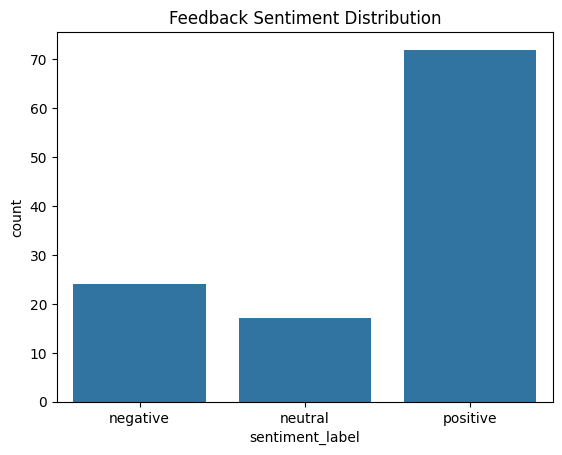

In [4]:
            print(df["sentiment_label"].value_counts())
            sns.countplot(data=df, x="sentiment_label", order=["negative", "neutral", "positive"])
            plt.title("Feedback Sentiment Distribution")
            plt.show()
            


In [5]:
            X_train, X_test, y_train, y_test = train_test_split(
                df["feedback_text"],
                df["sentiment_label"],
                test_size=0.25,
                random_state=42,
                stratify=df["sentiment_label"],
            )

            model = Pipeline(
                [
                    ("tfidf", TfidfVectorizer(stop_words="english")),
                    ("clf", LogisticRegression(max_iter=1000)),
                ]
            )
            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            print(classification_report(y_test, pred))
            


              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         6
     neutral       1.00      1.00      1.00         4
    positive       1.00      1.00      1.00        19

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



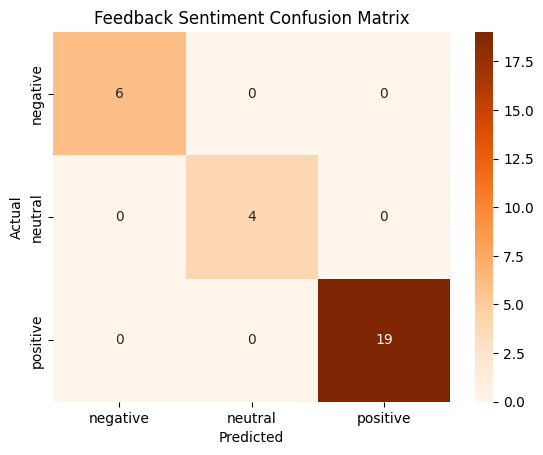

In [6]:
            cm = confusion_matrix(y_test, pred, labels=["negative", "neutral", "positive"])
            sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                cmap="Oranges",
                xticklabels=["negative", "neutral", "positive"],
                yticklabels=["negative", "neutral", "positive"],
            )
            plt.title("Feedback Sentiment Confusion Matrix")
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.show()
            


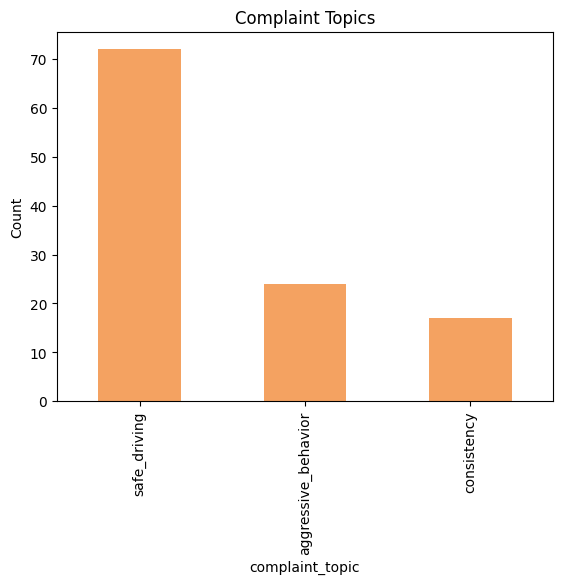

In [7]:
            topic_counts = df["complaint_topic"].value_counts()
            topic_counts.plot(kind="bar", color="#f4a261")
            plt.title("Complaint Topics")
            plt.ylabel("Count")
            plt.show()
            


Interpretation

The NLP model performed very well and correctly classified all test feedback as negative, neutral, or positive. This means the feedback text was easy for the model to separate by sentiment.

The most common feedback topic was safe driving, followed by aggressive behavior and consistency. Most passenger feedback was positive, with fewer neutral and negative comments.

Overall, the NLP module helps the driver monitoring dashboard understand not only whether feedback is good or bad, but also why. It can help identify drivers with repeated negative feedback and show whether the issue is related to safety, aggressive driving, reliability, or ride quality.
            
